# WPO 4: Designing an MDP

Design a Gymnasium capable environment using the description below. For more information about the Gymnasium interface, visit https://gymnasium.farama.org/api/env/.

## Description
**State Space**: 2 floats, time_of_day (from 0 at midnight to 1 at midnight the next day) and current_temperature (from -20 to -5).<br>
**Action Space**: 1 float, cooling strength (from 0 to 1)

**Effect of the actions**:
- One episode is one day
- One day is 24 hours. The agent controls every hour (so, 24 time-steps per episode)
- At the beginning of an episode, the fridge temperature is a random number between -19 and -16 (it is a float)
- Fridges warm up when food is put in them and the door is opened. The amount of watts (W) of heat added to the fridge, for every hour, is in WATTS_IN. This needs to be multiplied with a random number between 0.9 and 1.1
- Refrigeration units are able to cool down from 0 watts (action = 0) to 500 watts (action = 1)
- To have this cooling action, the refrigeration unit consumes an amount of electrical power equal to cooling [see point above] * 2.0 * exp(-fridge_temperature / 20   -   1)
- After an hour, the temperature of the fridge will have changed by (watts in - watts cooled) * THERMAL_INERTIA
- You now have a new temperature :)

**Reward function**: The reward is equal to 1 - electrical consumption during the time-step / 1000<br>
**Termination function**: The episode terminates if the temperature of the fridge goes below -20C or above -15C. It also terminates after 24 hours.

In [1]:
import gymnasium as gym
import numpy as np

try:
    import stable_baselines3 as sb3
except ImportError:
    %pip install stable-baselines3
    try:
        import stable_baselines3 as sb3
    except ImportError:
        raise ImportError("stable-baselines3 is required to run this notebook. Please install it via pip.")

WATTS_IN = [50, 55, 38, 41, 800, 750, 450, 300, 450, 100, 210, 600, 450, 120, 80, 350, 220, 810, 420, 250, 80, 45, 61, 55]
THERMAL_INERTIA = 0.002

class FridgeEnv(gym.Env):
    def __init__(self, noise:float=0.0):
        self.observation_space = gym.spaces.Box(low=np.array([0.0, -20.0 - noise], dtype=np.float32), high=np.array([1.0, -5.0 + noise], dtype=np.float32), shape=(2,), dtype=np.float32)
        self.action_space = gym.spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        self.noise = noise

    def reset(self, **kwargs):
        self.current_time_of_day = 0
        self.current_temperature = np.random.uniform(-19, -16)

        return self.make_state(), {}

    def step(self, action):
        # TODO: Implement the step function following the description above
        # Opening the door warms up the fridge 
        watts_entering_fridge = WATTS_IN[self.current_time_of_day] 
        watts_entering_fridge *= 0.9 + np.random.random() * 0.2 

        # The cooling system cools down the fridge 
        watts_leaving_fridge = action[0] * 500.0 

        # Electrical power consumed 
        watts_of_electricity = watts_leaving_fridge * 2.0 * np.exp(-self.current_temperature / 20.0 - 1.0) 

        # Update temperature and time of day 
        self.current_temperature += (watts_entering_fridge - watts_leaving_fridge) * THERMAL_INERTIA 
        self.current_time_of_day +=1

        # Compute reward 
        reward = 1.0 - watts_of_electricity / 1000 
            
        done = (self.current_temperature > -15.0) or (self.current_temperature < -20.0) or self.current_time_of_day >= 24 
        return self.make_state(), reward, done, False, {}

    def make_state(self):
        return np.array([
            self.current_time_of_day / 24.0,
            self.current_temperature + (np.random.random() - 0.5) * self.noise # We decided to go for a uniform noise in the range [-noise, noise]
        ], dtype=np.float32)

# Test one episode
env = FridgeEnv()
done = False
state, _ = env.reset()

while not done:
    action = env.action_space.sample()
    state, reward, done, truncated, _ = env.step(action)

    print(state, action, reward)

    done = done | truncated

[  0.04166667 -16.901484  ] [0.25534913] 0.7830460722260583
[  0.08333334 -16.952518  ] [0.16701017] 0.85695934
[  0.125    -16.993246] [0.11689185] 0.8996288
[  0.16666667 -17.348186  ] [0.43565857] 0.6251518
[  0.20833333 -15.9079685 ] [0.1714156] 0.8498702
[  0.25    -14.94982] [0.68596315] 0.44095927


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 8.59         |
|    ep_rew_mean          | 6.41         |
| time/                   |              |
|    fps                  | 2699         |
|    iterations           | 4            |
|    time_elapsed         | 3            |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0020708977 |
|    clip_fraction        | 0.0537       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.39        |
|    explained_variance   | 0.376        |
|    learning_rate        | 0.0003       |
|    loss                 | 1.03         |
|    n_updates            | 30           |
|    policy_gradient_loss | -0.00565     |
|    std                  | 0.968        |
|    value_loss           | 2.48         |
---

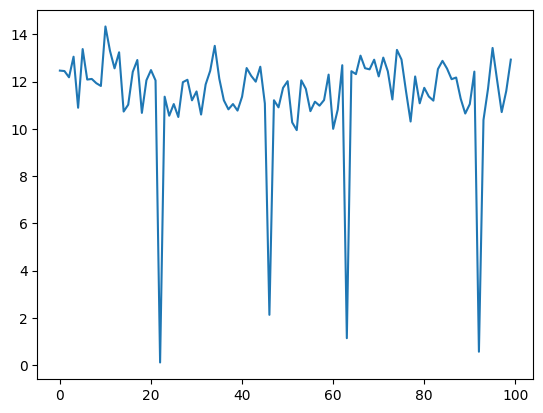

In [2]:
# Use PPO to learn in the environment for 20K time-steps

env = FridgeEnv(noise=0.0)
env = gym.wrappers.RecordEpisodeStatistics(env)  # Allows to get nice learning curves without using Tensorboard

agent = sb3.PPO( 
    "MlpPolicy", 
    env=env,
    verbose=1
) 

agent.learn(total_timesteps=40_000, log_interval=4) 


# Re-run this cell: Check what happens if you add noise to the temperature sensor 0.1, 0.5, 1.0

%pylab inline
import matplotlib.pyplot as plt

plt.plot(env.return_queue)